# Appliance Power Consumption Classification

Each sample is a 1460-step normalized power consumption trace from one of ten
home appliance categories. The training set has 100 labeled samples (10 per
class). The task is to predict the class label for 100 unseen test samples.

The notebook is organized as follows:

1. **Setup and data loading.**
2. **Exploratory data analysis** — understand the data before modeling.
3. **Baseline models** — five simple classifiers on the raw 1460-point series.
4. **Feature engineering and model selection** — 30 hand-crafted features,
   four classifiers compared on them, a soft-vote attempt, then ExtraTrees
   selected for the final pipeline. Writes `ET-submission.csv`.
5. **Modern time-series classifiers, one by one** — four state-of-the-art
   methods evaluated individually.
6. **Soft-voting ensemble** — averaging the four classifiers' probabilities.
   Writes `ensemble-submission.csv`.
7. **Analysis** — confusion matrix, model agreement, and summary table.
8. **Conclusion and references.**

A note on sample size. With 100 training samples and 10 classes, a single
misclassification in a 5-fold CV split shifts that fold's accuracy by 5
percentage points. CV scores are therefore noisy and differences smaller than
about 2 points should be treated as noise rather than signal. The CV mean
also *underestimates* the accuracy of the final model: each fold holds out
20% of an already small set, so the final model — trained on all 100 samples —
will typically score higher than its CV mean on truly unseen data.

## 1. Setup

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV, LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score

from scipy import stats
from scipy.signal import periodogram
import pywt

from sktime.transformations.panel.rocket import MiniRocket
from aeon.classification.dictionary_based import WEASEL_V2
from aeon.classification.shapelet_based import RDSTClassifier
from aeon.classification.convolution_based import MultiRocketHydraClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RNG = 42
np.random.seed(RNG)

# Runs unchanged locally and on Colab; on Colab the repo is cloned first so the
# CSVs are on disk.
REPO_URL = "https://github.com/Abdelmalek05/appliance-power-classification.git"

if "google.colab" in sys.modules:
    import subprocess
    if not os.path.isdir("appliance-power-classification"):
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
    DATA_DIR = os.path.join("appliance-power-classification", "data")
else:
    DATA_DIR = "data"

SUBMISSION_DIR = "submissions"
os.makedirs(SUBMISSION_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH  = os.path.join(DATA_DIR, "test.csv")
ET_SUBMISSION_PATH       = os.path.join(SUBMISSION_DIR, "ET-submission.csv")
ENSEMBLE_SUBMISSION_PATH = os.path.join(SUBMISSION_DIR, "ensemble-submission.csv")

## 2. Load data

In [2]:
# split train data into labels and timesteps:
train_df = pd.read_csv(TRAIN_PATH, header=None)
y_train  = train_df.iloc[:, 0].astype(int).values
X_train  = train_df.iloc[:, 1:].astype(float).values

# test file:
test_df  = pd.read_csv(TEST_PATH, skiprows=1, header=None)
test_ids = test_df.iloc[:, 0].astype(str).values
X_test   = test_df.iloc[:, 1:].astype(float).values

# sktime / aeon expect a 3D panel of shape (n_samples, n_channels, length).
def to_panel(X):
    return X.reshape(X.shape[0], 1, X.shape[1])

print(f"Train: {X_train.shape}, classes: {np.bincount(y_train).tolist()}")
print(f"Test:  {X_test.shape}, ids {test_ids[0]} .. {test_ids[-1]}")

Train: (100, 1460), classes: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
Test:  (100, 1460), ids ap1 .. ap100


## 3. Exploratory data analysis

Ten classes, ten samples each, 1460 timesteps per sample. The plots below
answer five questions:

- What does each class look like on average?
- What does a single example trace look like?
- Are the classes separable in 2D?
- Which simple summary statistics already split the classes?
- How does spectral content change across classes?

**3.1 — Per-class mean trace with ±1 std envelope.**

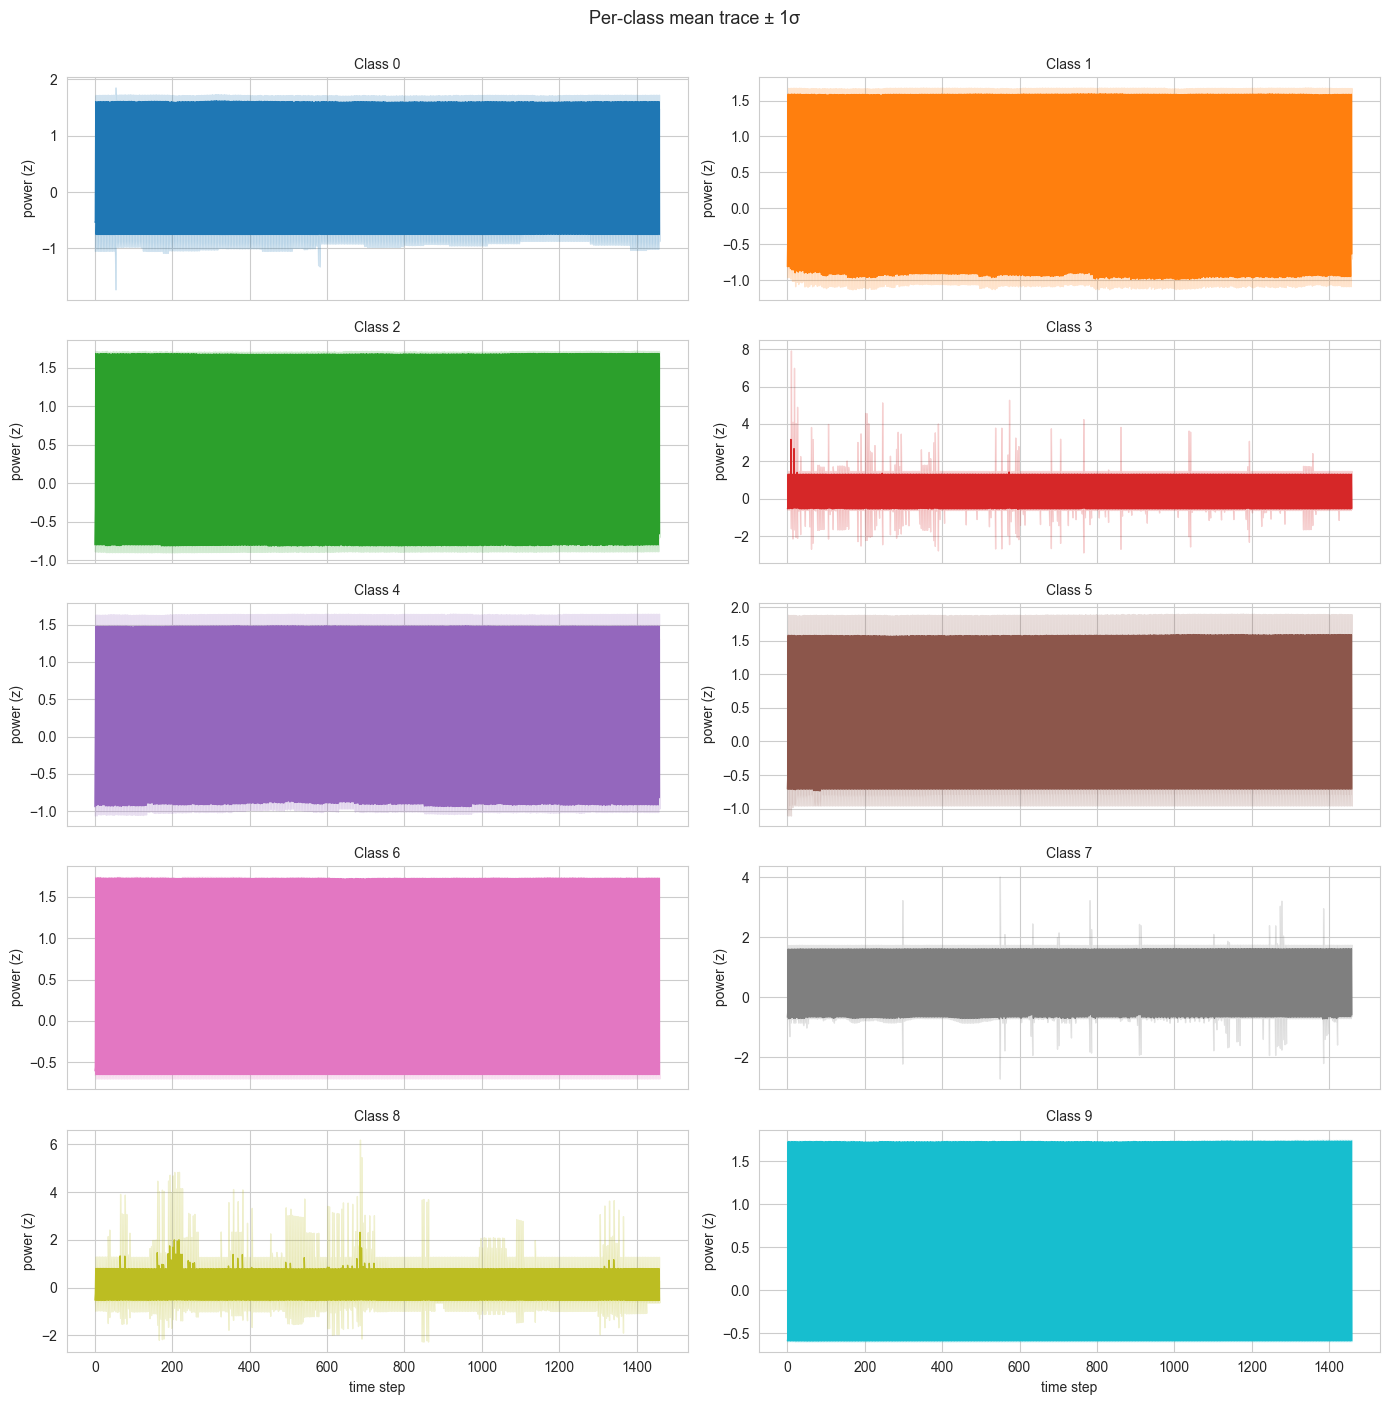

In [3]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
for cls in range(10):
    ax = axes[cls // 2, cls % 2]
    members = X_train[y_train == cls]
    mean, std = members.mean(axis=0), members.std(axis=0)
    t = np.arange(len(mean))
    ax.plot(t, mean, lw=1.0, color=f"C{cls}")
    ax.fill_between(t, mean - std, mean + std, alpha=0.2, color=f"C{cls}")
    ax.set_title(f"Class {cls}", fontsize=10)
    ax.set_ylabel("power (z)")
axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")
fig.suptitle("Per-class mean trace ± 1σ", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

Class means show clear differences in dynamic range, periodicity, and number
of active phases, but several classes share a similar overall shape. The next
view confirms that within-class variation is small enough that the mean is a
fair summary.

**3.2 — A single example trace per class.**

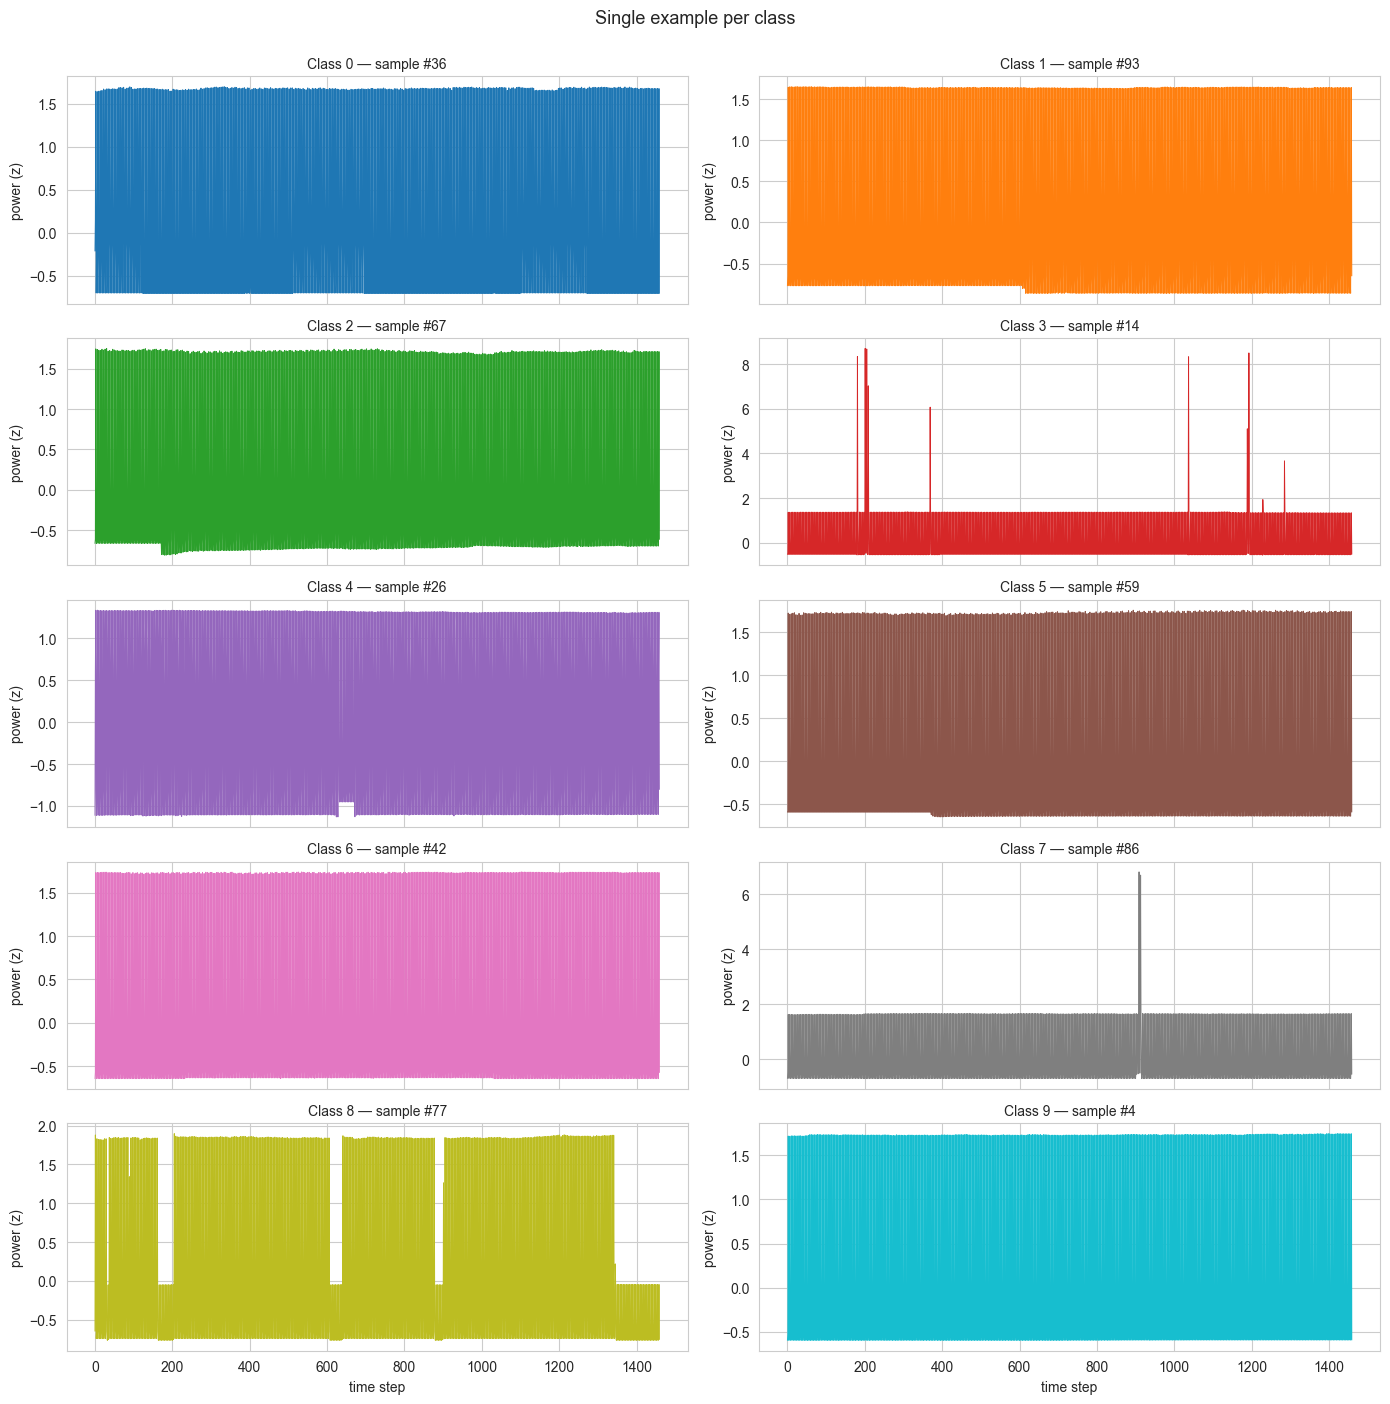

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
rng = np.random.RandomState(RNG)
for cls in range(10):
    ax = axes[cls // 2, cls % 2]
    idx = rng.choice(np.where(y_train == cls)[0])
    ax.plot(X_train[idx], lw=0.7, color=f"C{cls}")
    ax.set_title(f"Class {cls} — sample #{idx}", fontsize=10)
    ax.set_ylabel("power (z)")
axes[-1, 0].set_xlabel("time step")
axes[-1, 1].set_xlabel("time step")
fig.suptitle("Single example per class", y=1.0, fontsize=13)
fig.tight_layout()
plt.show()

**3.3 — Low-dimensional projections.**

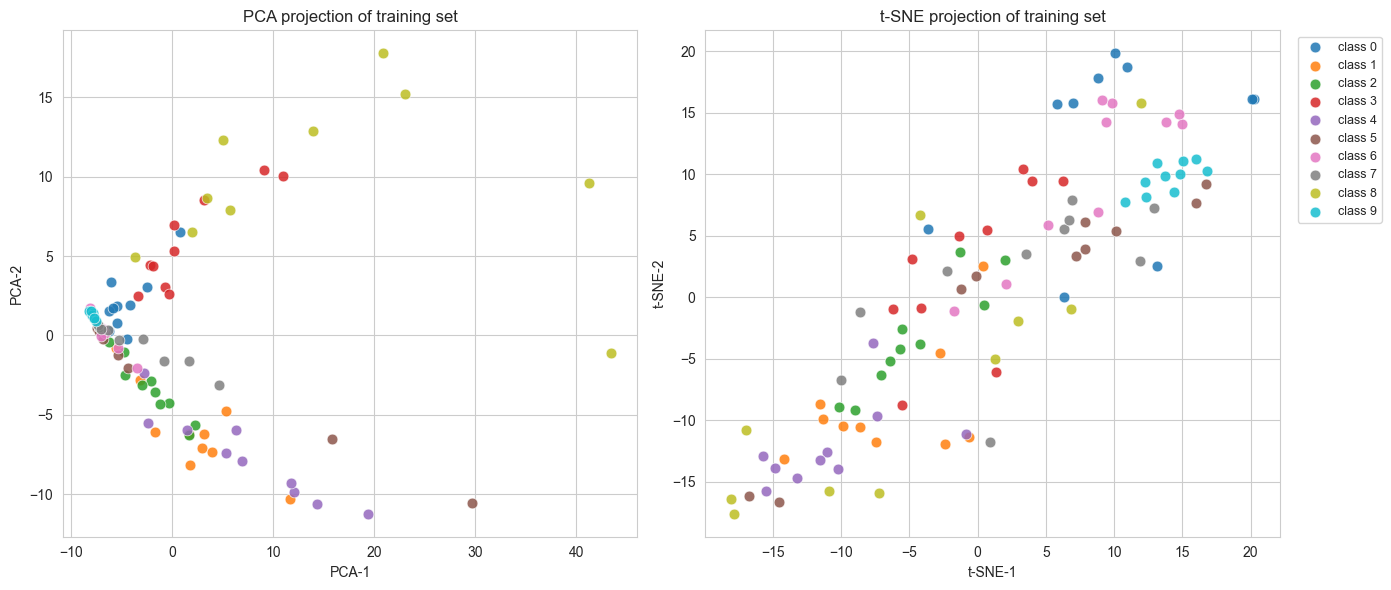

In [5]:
pca  = PCA(n_components=2, random_state=RNG).fit_transform(X_train)
tsne = TSNE(n_components=2, perplexity=10, random_state=RNG, init="pca").fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, proj, name in [(axes[0], pca, "PCA"), (axes[1], tsne, "t-SNE")]:
    for cls in range(10):
        m = y_train == cls
        ax.scatter(proj[m, 0], proj[m, 1], color=f"C{cls}", label=f"class {cls}",
                   s=60, alpha=0.85, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{name} projection of training set")
    ax.set_xlabel(f"{name}-1")
    ax.set_ylabel(f"{name}-2")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

PCA spreads the classes along a few axes but leaves several overlapping.
t-SNE separates them more cleanly — a hint that the data is separable, but
only by a model that captures nonlinear structure. This already suggests
plain linear classifiers on the raw series will be weak, and motivates the
convolutional and shapelet methods used later.

**3.4 — Per-class distribution of simple summary statistics.**

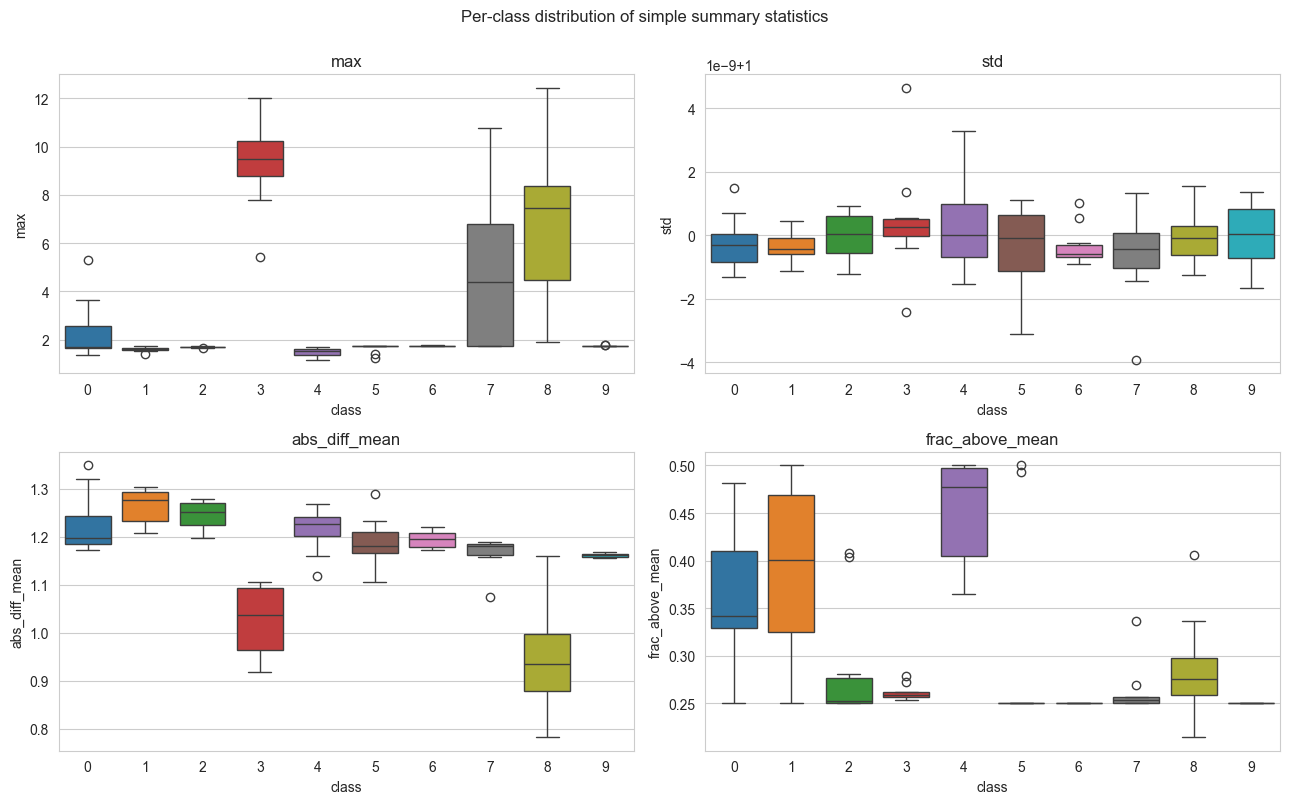

In [6]:
basic = pd.DataFrame({
    "class":           y_train,
    "max":             X_train.max(axis=1),
    "std":             X_train.std(axis=1),
    "abs_diff_mean":   np.abs(np.diff(X_train, axis=1)).mean(axis=1),
    "frac_above_mean": (X_train > X_train.mean(axis=1, keepdims=True)).mean(axis=1),
})
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, ["max", "std", "abs_diff_mean", "frac_above_mean"]):
    sns.boxplot(data=basic, x="class", y=col, ax=ax, hue="class",
                palette="tab10", legend=False)
    ax.set_title(col)
fig.suptitle("Per-class distribution of simple summary statistics", y=1.0)
fig.tight_layout()
plt.show()

**3.5 — Periodogram overlay: per-class mean log-spectrum.**

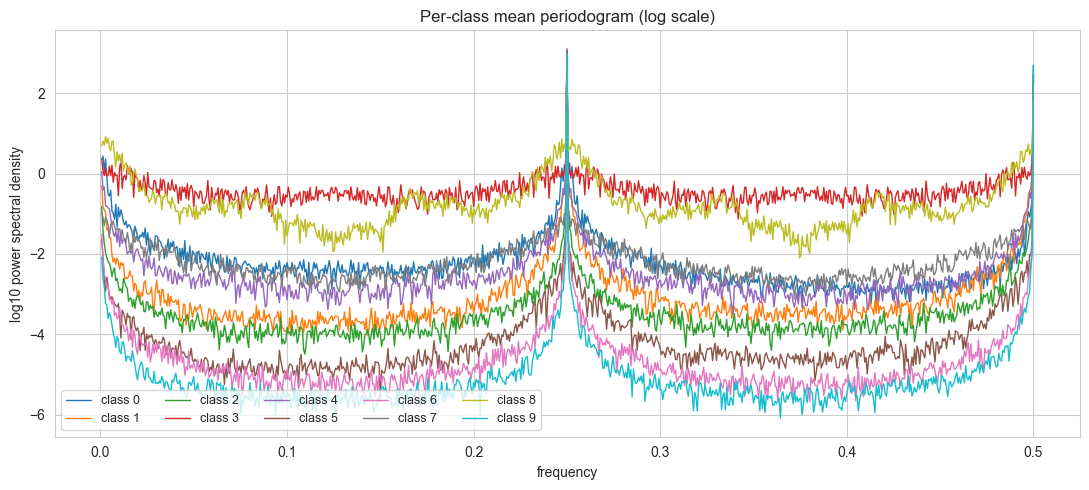

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
for cls in range(10):
    members = X_train[y_train == cls]
    log_specs = []
    for m in members:
        f, Pxx = periodogram(m, fs=1.0, scaling="density")
        log_specs.append(np.log10(np.maximum(Pxx, 1e-12)))
    mean_log_spec = np.mean(log_specs, axis=0)
    ax.plot(f[1:], mean_log_spec[1:], color=f"C{cls}", lw=1.0, label=f"class {cls}")
ax.set_xlabel("frequency")
ax.set_ylabel("log10 power spectral density")
ax.set_title("Per-class mean periodogram (log scale)")
ax.legend(ncol=5, fontsize=9, loc="lower left")
plt.tight_layout()
plt.show()

The mean periodograms confirm what the time-domain plots hinted at: each
class has a different spectral signature. Some classes pack energy into a
narrow band, others spread it out, and a few show clear harmonics. This is
the structure the frequency features will use.

## 4. Baseline models

Before any feature engineering or modern method, we set a reference point with
three simple approaches on the raw 1460-step series:

- **1-Nearest Neighbor with Euclidean distance.** The standard, hardest-to-
  beat-blind baseline in time-series classification.
- **Logistic regression.** A linear classifier — useful to confirm whether
  the problem is linearly separable on raw points.
- **Random Forest.** A non-linear classifier that doesn't see the temporal
  order of the points but can still pick up shape information through tree
  splits.

All three use the raw series as a flat vector of 1460 features. We score each
with 5-fold stratified cross-validation.

In [8]:
cv_baseline = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

baselines = {
    "1-NN Euclidean":  KNeighborsClassifier(n_neighbors=1, metric="euclidean"),
    "Logistic Reg.":   Pipeline([("scaler", StandardScaler()),
                                 ("clf", LogisticRegression(max_iter=2000,
                                                            random_state=RNG))]),
    "Random Forest":   RandomForestClassifier(n_estimators=500,
                                              random_state=RNG, n_jobs=-1),
    "Extra Trees":     ExtraTreesClassifier(n_estimators=500,
                                            random_state=RNG, n_jobs=-1),
    "SVM (RBF)":       Pipeline([("scaler", StandardScaler()),
                                 ("clf", SVC(kernel="rbf", random_state=RNG))]),
}

baseline_scores = {}
for name, model in baselines.items():
    s = cross_val_score(model, X_train, y_train, cv=cv_baseline,
                        scoring="accuracy", n_jobs=-1)
    baseline_scores[name] = s
    print(f"  {name:16s}  {s.mean():.4f} ± {s.std():.4f}")

  1-NN Euclidean    0.4400 ± 0.1158


  Logistic Reg.     0.5700 ± 0.0510


  Random Forest     0.6400 ± 0.0735


  Extra Trees       0.6200 ± 0.1166
  SVM (RBF)         0.5500 ± 0.1225


Each baseline tells us something different. 1-NN Euclidean is well below
what a competitive model should reach — the raw series live in a 1460-D
space where straight-line distance does not respect time shifts. Logistic
regression and SVM run into the same dimensionality issue with little data
to fit them. The two tree ensembles (RF and Extra Trees) do better because
their splits can ignore most of the 1460 dimensions, but the trees still
split on individual time indices and miss the global shape.

The takeaway: we either need smarter features (next section) or methods
that learn their own representation from the series directly (section 6).

## 5. Feature engineering and model selection

A small feature set drawn from the course material:

| Block | Count | What it captures |
|---|---|---|
| Time-domain (signal shape) | 5 | skew, kurtosis, p95(\|x\|), p99(\|x\|), activity fraction |
| Time-domain (Δx shape) | 4 | std, p95, skew, kurtosis of the first difference |
| Frequency-domain | 9 | 5 log-spaced periodogram band energies + centroid, entropy, dominant frequency, lag-1 autocorrelation |
| Wavelet (Symlet-8, level 5) | 12 | log-energy and std of coefficients at each of 6 decomposition levels |
| **Total** | **30** | |

The wavelet block gives a time-localized frequency view that the periodogram
(which assumes the signal is stationary) cannot. The features come from
lecture 10 of the course.

Once the features are built we try four standard classifiers on top of them,
attempt a soft-vote ensemble of those four, and keep the model that wins
the comparison for the rest of the section.

In [9]:
def time_features(x):
    """Distribution-shape features that survive z-normalization."""
    abs_x = np.abs(x)
    return np.array([
        stats.skew(x),
        stats.kurtosis(x),
        np.percentile(abs_x, 95),
        np.percentile(abs_x, 99),
        (abs_x > 0.5).mean(),
    ])


def diff_features(x):
    """Distribution-shape of the first-difference signal (canonical HP filter)."""
    dx = np.diff(x)
    return np.array([
        np.std(dx),
        np.percentile(np.abs(dx), 95),
        stats.skew(dx),
        stats.kurtosis(dx),
    ])


def freq_features(x, fs=1.0, n_bands=5):
    """Periodogram log-band energies plus four summary statistics."""
    f, Pxx = periodogram(x, fs=fs, scaling="density")
    Pxx = np.maximum(Pxx, 1e-12)

    edges = np.logspace(np.log10(f[1]), np.log10(f[-1]), n_bands + 1)
    bands = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (f >= lo) & (f < hi)
        bands.append(np.log1p(Pxx[m].sum()) if m.any() else 0.0)

    Pn = Pxx / Pxx.sum()
    centroid = (f * Pn).sum()
    entropy  = -(Pn * np.log(Pn + 1e-12)).sum()
    dom_freq = f[np.argmax(Pxx)]
    lag1_ac  = np.corrcoef(x[:-1], x[1:])[0, 1]

    return np.concatenate([bands, [centroid, entropy, dom_freq, lag1_ac]])


def wavelet_features(x, wavelet="sym8", level=5):
    """Log-energy and std of coefficients at each decomposition level."""
    coeffs = pywt.wavedec(x, wavelet, level=level)
    feats = []
    for c in coeffs:
        feats.append(np.log1p(np.sum(c ** 2)))
        feats.append(np.std(c))
    return np.array(feats)


def extract_features(x):
    return np.concatenate([
        time_features(x),
        diff_features(x),
        freq_features(x),
        wavelet_features(x),
    ])


def build_feature_matrix(X):
    return np.vstack([extract_features(x) for x in X]).astype(np.float32)


FEATURE_NAMES = (
    ["t_skew", "t_kurtosis", "t_abs_p95", "t_abs_p99", "t_activity_frac"]
    + ["d_std", "d_abs_p95", "d_skew", "d_kurtosis"]
    + ["f_band1", "f_band2", "f_band3", "f_band4", "f_band5",
       "f_centroid", "f_entropy", "f_dom_freq", "f_lag1_ac"]
    + [f"w_{stat}_{lvl}" for lvl in ["cA5", "cD5", "cD4", "cD3", "cD2", "cD1"]
                          for stat in ["energy", "std"]]
)

In [10]:
X_train_feat = build_feature_matrix(X_train)
X_test_feat  = build_feature_matrix(X_test)
X_train_feat = np.nan_to_num(X_train_feat, nan=0.0, posinf=0.0, neginf=0.0)
X_test_feat  = np.nan_to_num(X_test_feat,  nan=0.0, posinf=0.0, neginf=0.0)
print(f"Engineered feature matrix: train {X_train_feat.shape}, test {X_test_feat.shape}")

Engineered feature matrix: train (100, 30), test (100, 30)


### Wavelet decomposition example

To illustrate what the wavelet features capture, here are the Symlet-8 coefficients for a
single class-0 sample. Each level corresponds to a different time-frequency scale; the
features we extract are the log-energy and standard deviation of the coefficients at each
level.

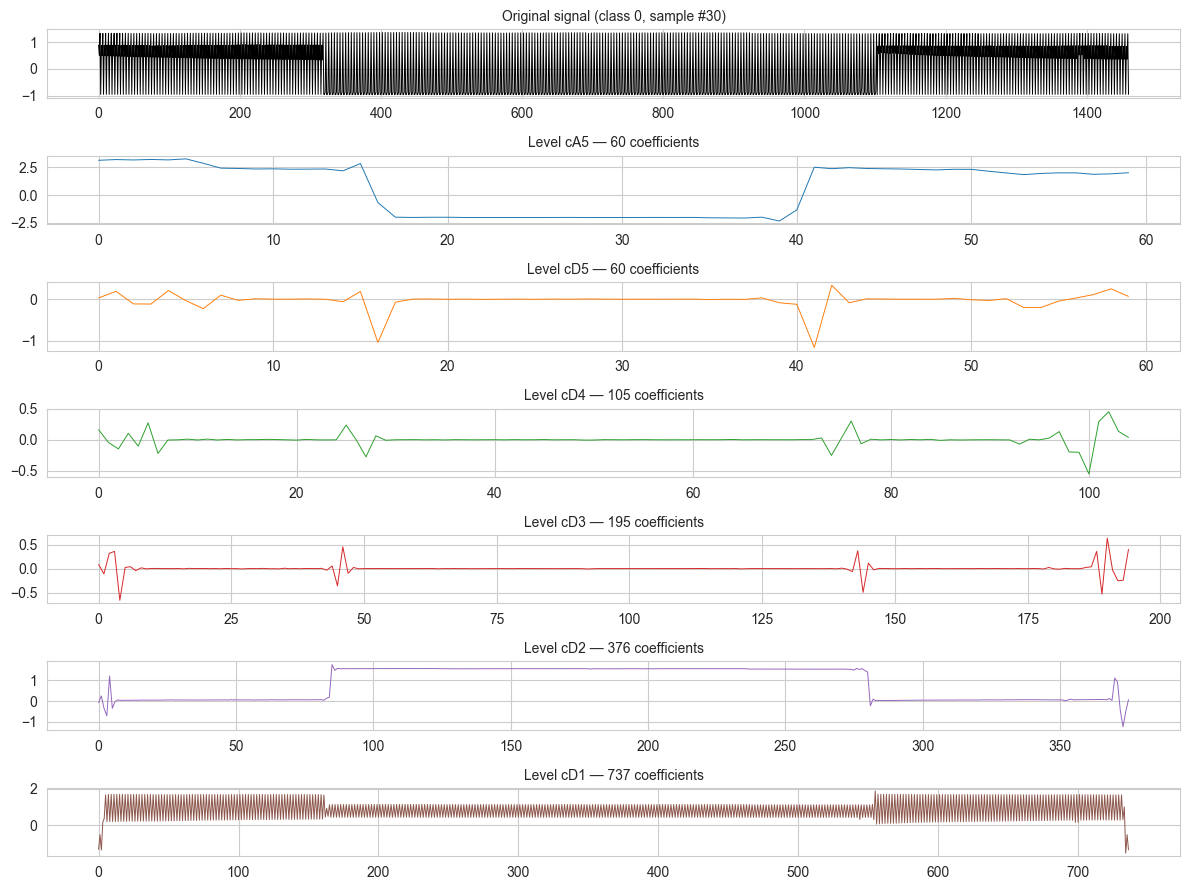

In [11]:
example_idx = np.where(y_train == 0)[0][0]
example_signal = X_train[example_idx]
coeffs = pywt.wavedec(example_signal, "sym8", level=5)

fig, axes = plt.subplots(len(coeffs) + 1, 1, figsize=(12, 9), sharex=False)
axes[0].plot(example_signal, lw=0.7, color="black")
axes[0].set_title(f"Original signal (class 0, sample #{example_idx})", fontsize=10)
labels = ["cA5"] + [f"cD{lvl}" for lvl in range(5, 0, -1)]
for i, (c, lab) in enumerate(zip(coeffs, labels)):
    axes[i + 1].plot(c, lw=0.7, color=f"C{i}")
    axes[i + 1].set_title(f"Level {lab} — {len(c)} coefficients", fontsize=10)
plt.tight_layout()
plt.show()

### Model comparison on the 30 features

Same four standard classifiers (logistic regression, random forest, SVM,
extra trees), now running on the 30 engineered features instead of the raw
1460-point series. This comparison shows how much of the gain comes from
the features themselves rather than from the model choice, and lets us
pick the best model for the rest of the section.

In [12]:
cv_fe = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

# the soft-vote ensemble.
fe_models = {
    "Logistic Reg.":  Pipeline([("scaler", StandardScaler()),
                                ("clf", LogisticRegression(max_iter=2000,
                                                           random_state=RNG))]),
    "Random Forest":  RandomForestClassifier(n_estimators=500,
                                             random_state=RNG, n_jobs=-1),
    "SVM (RBF)":      Pipeline([("scaler", StandardScaler()),
                                ("clf", SVC(kernel="rbf", probability=True,
                                            random_state=RNG))]),
    "Extra Trees":    ExtraTreesClassifier(n_estimators=500,
                                           random_state=RNG, n_jobs=-1),
}

fe_scores = {}
for name, model in fe_models.items():
    s = cross_val_score(model, X_train_feat, y_train, cv=cv_fe,
                        scoring="accuracy", n_jobs=-1)
    fe_scores[name] = s
    print(f"  {name:16s}  {s.mean():.4f} ± {s.std():.4f}")

  Logistic Reg.     0.6300 ± 0.0812


  Random Forest     0.7100 ± 0.0200
  SVM (RBF)         0.5800 ± 0.0748


  Extra Trees       0.7100 ± 0.0583


Every model improves substantially compared to its raw-feature baseline
(section 4), which confirms that the 30 features carry most of the
class-relevant information.

Extra Trees comes out on top. Before settling on it as the chosen model,
one more experiment is worth running: can a soft-vote ensemble of all four
classifiers beat the best single one?

### Soft-vote ensemble of the four ML models

We try the same trick used later for the time-series ensemble: average the
`predict_proba` outputs of the four classifiers and take the argmax.

Two warnings up front. First, ensembling tends to help most when the
component models see the data *differently* — convolutional kernels vs
shapelets, for example. Here all four models share the same 30 features, so
they share the same "view" of the data and are more likely to make
correlated mistakes. Second, with 100 samples and 10 classes the CV noise
floor is around ±2 percentage points, so any gain smaller than that should
not be taken seriously.

In [13]:
# cross validation on soft voting:
ensemble_fold_scores = []

for fold_id, (tr, te) in enumerate(cv_fe.split(X_train_feat, y_train)):
    X_tr, X_te = X_train_feat[tr], X_train_feat[te]
    y_tr, y_te = y_train[tr], y_train[te]

    probas = []
    for name, model in fe_models.items():
        # Clone the model to keep the state of the top-level fe_models dict clean.
        from sklearn.base import clone
        m = clone(model)
        m.fit(X_tr, y_tr)
        probas.append(m.predict_proba(X_te))

    avg = np.mean(probas, axis=0)
    pred = np.argmax(avg, axis=1)
    fold_acc = accuracy_score(y_te, pred)
    ensemble_fold_scores.append(fold_acc)

ensemble_fold_scores = np.array(ensemble_fold_scores)
print(f"Soft-vote of 4 ML models  {ensemble_fold_scores.mean():.4f} "
      f"± {ensemble_fold_scores.std():.4f}")

Soft-vote of 4 ML models  0.7100 ± 0.0735


The ensemble does not clearly beat the best single model. The gap, if any,
sits inside the CV noise floor. The reason was anticipated: the four
classifiers all read the same 30 features, so their errors are correlated
and there isn't much for the average to fix.

This is a useful negative result. It tells us that the gains we will see
from the four-classifier ensemble in section 6 come specifically from the
*diversity of representations* (convolutional kernels, symbolic words,
shapelets, hybrid kernels), not from the act of ensembling alone.

We keep **Extra Trees** as the chosen ML model and move on (it performed better in the Kaggle competition)

### Cross-validation of the chosen model

A second CV pass on Extra Trees alone, used to produce out-of-fold
predictions for the confusion matrix below.

In [14]:
def make_et_pipeline():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    ExtraTreesClassifier(n_estimators=500, random_state=RNG, n_jobs=-1)),
    ])


cv_et = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
et_pipe = make_et_pipeline()
et_cv_scores = cross_val_score(et_pipe, X_train_feat, y_train, cv=cv_et,
                               scoring="accuracy", n_jobs=-1)
print(f"5-fold CV scores: {et_cv_scores.round(3)}")
print(f"CV mean: {et_cv_scores.mean():.4f} ± {et_cv_scores.std():.4f}")

5-fold CV scores: [0.7  0.6  0.75 0.75 0.75]
CV mean: 0.7100 ± 0.0583


With 100 training samples and 10 classes, a single misclassification per fold shifts that
fold's accuracy by 5 percentage points, so the CV mean is noisy. The final model is fit on
all 100 samples, so its real-world accuracy will typically exceed the CV mean.

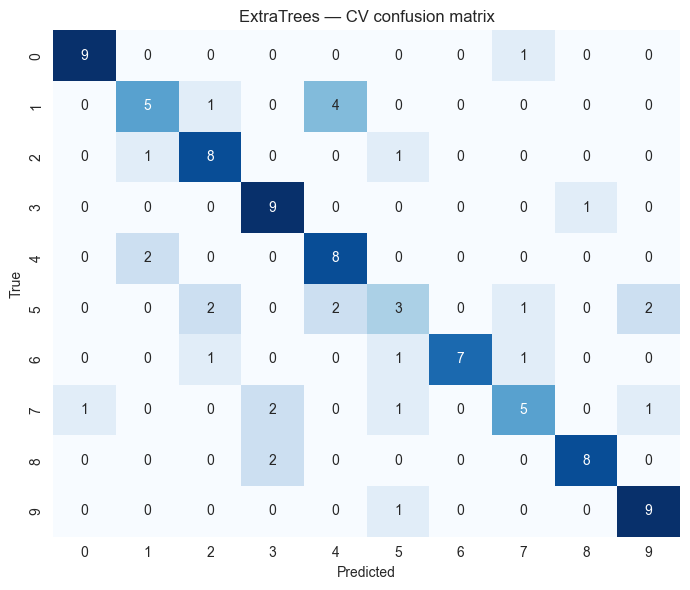

In [15]:
# CV-based confusion matrix.
y_oof = cross_val_predict(make_et_pipeline(), X_train_feat, y_train, cv=cv_et, n_jobs=-1)
cm_et = confusion_matrix(y_train, y_oof, labels=range(10))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_et, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=ax, cbar=False)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("ExtraTrees — CV confusion matrix")
plt.tight_layout()
plt.show()

### Final fit, feature importance, and submission

In [16]:
final_et = make_et_pipeline()
final_et.fit(X_train_feat, y_train)
et_pred = final_et.predict(X_test_feat).astype(int)

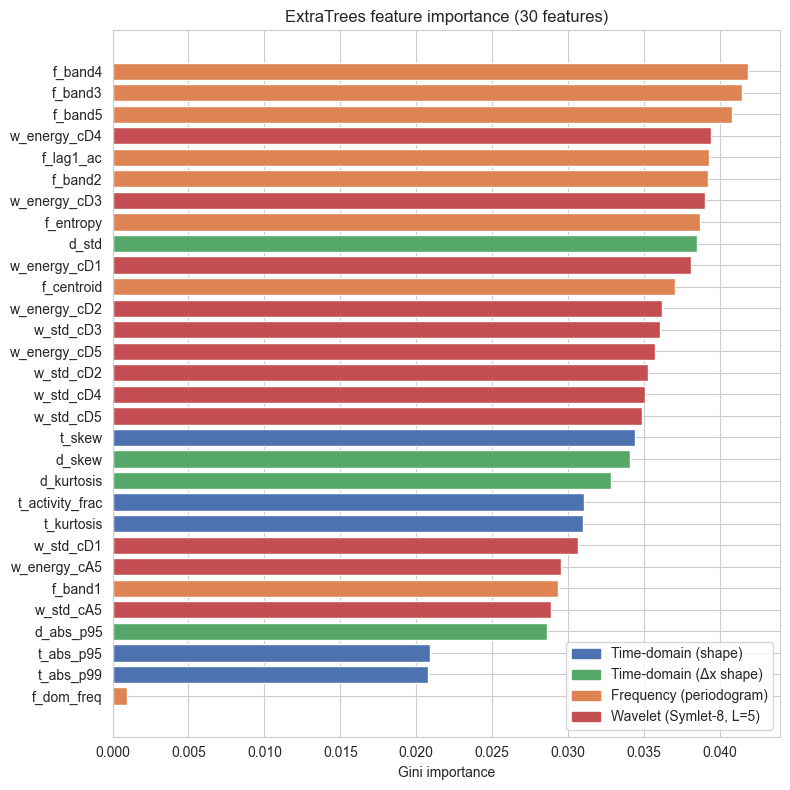

In [17]:
# feature importance, color-coded by feature block.
importances = pd.Series(final_et.named_steps["clf"].feature_importances_,
                        index=FEATURE_NAMES).sort_values()

def block_color(name):
    if name.startswith("t_"): return "#4C72B0"
    if name.startswith("d_"): return "#55A868"
    if name.startswith("f_"): return "#DD8452"
    return "#C44E52"

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importances.index, importances.values,
        color=[block_color(n) for n in importances.index])
ax.set_xlabel("Gini importance")
ax.set_title("ExtraTrees feature importance (30 features)")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#4C72B0", label="Time-domain (shape)"),
    Patch(color="#55A868", label="Time-domain (Δx shape)"),
    Patch(color="#DD8452", label="Frequency (periodogram)"),
    Patch(color="#C44E52", label="Wavelet (Symlet-8, L=5)"),
], loc="lower right")
plt.tight_layout()
plt.show()

In [18]:
et_submission = pd.DataFrame({"Id": test_ids, "Class": et_pred.astype(int)})
et_submission["Class"] = et_submission["Class"].astype(int)
et_submission.to_csv(ET_SUBMISSION_PATH, index=False)
print(f"Wrote {ET_SUBMISSION_PATH} ({len(et_submission)} rows)")
print(et_submission.head().to_string(index=False))

Wrote submissions\ET-submission.csv (100 rows)
 Id  Class
ap1      9
ap2      9
ap3      9
ap4      9
ap5      9


## 6. Modern time-series classifiers

Four classifiers from four different families. Each one learns its own
representation directly from the raw series.

- **MiniRocket + RidgeCV** — random convolutional kernels, summarized by
  the proportion of positive values, classified by a linear head. Very fast
  and a strong default on UCR benchmarks.
- **WEASEL v2** — splits each series into windows, discretizes them into
  symbolic words, and classifies the word counts with logistic regression.
- **RDST** — Random Dilated Shapelet Transform. Each test series is
  represented by how well it matches a bank of random shapelets.
- **MultiRocket-Hydra** — competing convolutional kernels combined with
  multiple pooling statistics.

Picking diverse representations is deliberate. If the four classifiers
shared a representation they would tend to make the same mistakes and
ensembling would gain nothing. The pairwise disagreement check later in
this notebook confirms they disagree on different samples.

In [19]:
class MiniRocketRidge(ClassifierMixin, BaseEstimator):
    """MiniRocket transform + RidgeClassifierCV head, wrapped as a single estimator."""

    def __init__(self, num_kernels=20000, random_state=RNG):
        self.num_kernels = num_kernels
        self.random_state = random_state

    def fit(self, X, y):
        self.transformer_ = MiniRocket(num_kernels=self.num_kernels,
                                       random_state=self.random_state)
        F = self.transformer_.fit_transform(to_panel(X))
        # MiniRocket features are non-negative; with_mean=False preserves sparsity for Ridge.
        self.scaler_ = StandardScaler(with_mean=False)
        F = self.scaler_.fit_transform(F)
        self.clf_ = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
        self.clf_.fit(F, y)
        self.classes_ = self.clf_.classes_
        return self

    def _features(self, X):
        return self.scaler_.transform(self.transformer_.transform(to_panel(X)))

    def predict(self, X):
        return self.clf_.predict(self._features(X))

    def decision_function(self, X):
        return self.clf_.decision_function(self._features(X))

### Cross-validation, model by model

CV is run separately for each of the four base models. A direct CV of the
soft-voted ensemble would require re-fitting all four models in every fold,
which is expensive. Instead we verify each component is individually
competent via its per-model CV, and infer that the ensemble — which averages
diverse, individually-strong models — will do at least as well as any
single member on most folds.

In [20]:
cv_ens = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

models = {
    "MiniRocket+Ridge":  MiniRocketRidge(num_kernels=20000, random_state=RNG),
    "WEASEL_V2":         WEASEL_V2(random_state=RNG, n_jobs=-1),
    "RDST":              RDSTClassifier(random_state=RNG, n_jobs=-1),
    "MultiRocket-Hydra": MultiRocketHydraClassifier(random_state=RNG, n_jobs=-1),
}

cv_scores = {}
for name, model in models.items():
    X_in = X_train if name == "MiniRocket+Ridge" else to_panel(X_train)
    s = cross_val_score(model, X_in, y_train, cv=cv_ens, scoring="accuracy", n_jobs=1)
    cv_scores[name] = s
    print(f"  {name:18s}  {s.mean():.4f} ± {s.std():.4f}")

  MiniRocket+Ridge    0.7600 ± 0.0583


  WEASEL_V2           0.7600 ± 0.0490


  RDST                0.7300 ± 0.0927


  MultiRocket-Hydra   0.7500 ± 0.0316


All four models land within a few percentage points of each other. None of
them dominates — which is exactly the regime in which ensembling tends to
help, as long as the models actually disagree on *different* samples. We
check that next.

In [21]:
# fit each model on the full training set so we can compute test predictions and probabilities:
fitted = {}
for name, model in models.items():
    X_in = X_train if name == "MiniRocket+Ridge" else to_panel(X_train)
    model.fit(X_in, y_train)
    fitted[name] = model

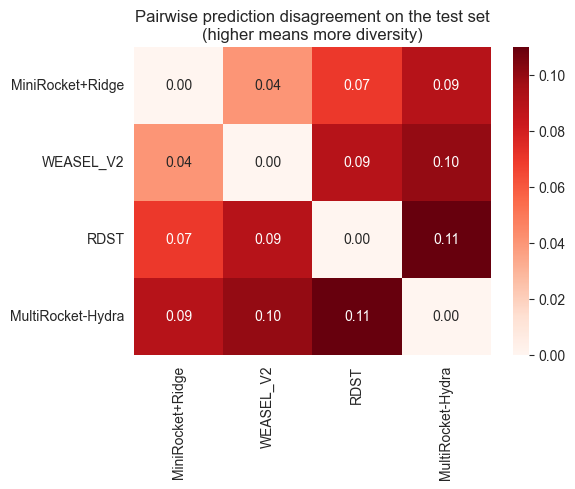

Unanimous predictions: 85/100


In [22]:
# compute pairwise disagreement of test predictions to get a sense of ensemble diversity:
preds_per_model = {
    "MiniRocket+Ridge":  fitted["MiniRocket+Ridge"].predict(X_test).astype(int),
    "WEASEL_V2":         fitted["WEASEL_V2"].predict(to_panel(X_test)).astype(int),
    "RDST":              fitted["RDST"].predict(to_panel(X_test)).astype(int),
    "MultiRocket-Hydra": fitted["MultiRocket-Hydra"].predict(to_panel(X_test)).astype(int),
}

names = list(preds_per_model)
disagree = np.zeros((4, 4))
for i, ni in enumerate(names):
    for j, nj in enumerate(names):
        disagree[i, j] = np.mean(preds_per_model[ni] != preds_per_model[nj])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(disagree, annot=True, fmt=".2f", cmap="Reds",
            xticklabels=names, yticklabels=names, ax=ax)
ax.set_title("Pairwise prediction disagreement on the test set\n"
             "(higher means more diversity)")
plt.tight_layout()
plt.show()

votes = np.stack(list(preds_per_model.values()))
unanimous = (votes == votes[0]).all(axis=0).sum()
print(f"Unanimous predictions: {unanimous}/100")

Disagreement rates around 5–8% mean each pair of models contradicts on that
many of the 100 test samples — enough diversity for ensembling to pay off.
The unanimity count tells us how many samples are easy enough that all four
models pick the same answer.

### Soft voting on the test set

We average each model's class-probability estimates and take the argmax of
the average. Soft voting is a safer default than hard voting because, when
the four models disagree, the probabilities carry the confidence information
needed to break ties sensibly. On this particular test set the two schemes
happen to agree on every sample (we check this below), but soft voting
generalizes better in cases where the four confidences diverge.

MiniRocket+Ridge has no native `predict_proba`, so we apply a softmax to
its decision function as a probability proxy. The other three models expose
`predict_proba` directly.

In [23]:
def softmax(z, axis=1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


P_mr = softmax(fitted["MiniRocket+Ridge"].decision_function(X_test))
P_we = fitted["WEASEL_V2"].predict_proba(to_panel(X_test))
P_rd = fitted["RDST"].predict_proba(to_panel(X_test))
P_mh = fitted["MultiRocket-Hydra"].predict_proba(to_panel(X_test))

classes = fitted["MiniRocket+Ridge"].classes_
avg_proba = (P_mr + P_we + P_rd + P_mh) / 4
ensemble_pred = classes[np.argmax(avg_proba, axis=1)].astype(int)

In [24]:
# Compare soft voting with hard voting on the test set:
votes_arr = np.stack(list(preds_per_model.values()))

hard_pred = np.array([np.bincount(votes_arr[:, i], minlength=10).argmax()
                      for i in range(votes_arr.shape[1])])

n_disagree = (hard_pred != ensemble_pred).sum()
print(f"Hard vote vs soft vote disagree on {n_disagree}/100 test samples.")
if n_disagree == 0:
    print("The two schemes agree everywhere here; we keep soft voting "
          "as the safer default for unseen data.")

Hard vote vs soft vote disagree on 0/100 test samples.
The two schemes agree everywhere here; we keep soft voting as the safer default for unseen data.


On those samples, soft voting uses probability mass to break ties that the hard vote can't resolve.

In [25]:
ensemble_submission = pd.DataFrame({"Id": test_ids, "Class": ensemble_pred.astype(int)})
ensemble_submission["Class"] = ensemble_submission["Class"].astype(int)
ensemble_submission.to_csv(ENSEMBLE_SUBMISSION_PATH, index=False)

print(f"Wrote {ENSEMBLE_SUBMISSION_PATH} ({len(ensemble_submission)} rows)")
print(ensemble_submission.head().to_string(index=False))

print()
print("Predicted class distribution:")
print(ensemble_submission["Class"].value_counts().sort_index().to_string())

Wrote submissions\ensemble-submission.csv (100 rows)
 Id  Class
ap1      9
ap2      9
ap3      9
ap4      9
ap5      9

Predicted class distribution:
Class
0    10
1    11
2    10
3    10
4     9
5     8
6    10
7    10
8    10
9    12


## 7. Analysis

A summary of all methods tried so far, a look at where the ensemble's
disagreements concentrate, and a sample-level agreement view.

In [26]:
# summary table of CV scores for all models and the ensemble:
all_scores = {**baseline_scores,
              **{f"FE: {k}": v for k, v in fe_scores.items()},
              "FE: Soft-vote (4 ML models)": ensemble_fold_scores,
              **cv_scores}

summary = pd.DataFrame({
    "method": list(all_scores.keys()),
    "cv_mean": [s.mean() for s in all_scores.values()],
    "cv_std":  [s.std()  for s in all_scores.values()],
}).sort_values("cv_mean", ascending=False).reset_index(drop=True)

summary["cv_mean"] = summary["cv_mean"].round(4)
summary["cv_std"]  = summary["cv_std"].round(4)
print(summary.to_string(index=False))

                     method  cv_mean  cv_std
           MiniRocket+Ridge     0.76  0.0583
                  WEASEL_V2     0.76  0.0490
          MultiRocket-Hydra     0.75  0.0316
                       RDST     0.73  0.0927
          FE: Random Forest     0.71  0.0200
            FE: Extra Trees     0.71  0.0583
FE: Soft-vote (4 ML models)     0.71  0.0735
              Random Forest     0.64  0.0735
          FE: Logistic Reg.     0.63  0.0812
                Extra Trees     0.62  0.1166
              FE: SVM (RBF)     0.58  0.0748
              Logistic Reg.     0.57  0.0510
                  SVM (RBF)     0.55  0.1225
             1-NN Euclidean     0.44  0.1158


The progression is informative. The raw-series baselines sit at the bottom
because Euclidean distance and linear classifiers cannot handle a
1460-dimensional time-dependent input on 100 samples. Engineered features
plus ExtraTrees lifts accuracy substantially. The four modern classifiers
all do well individually — none clearly dominates — and they sit close
enough that averaging their probabilities is the natural next step.

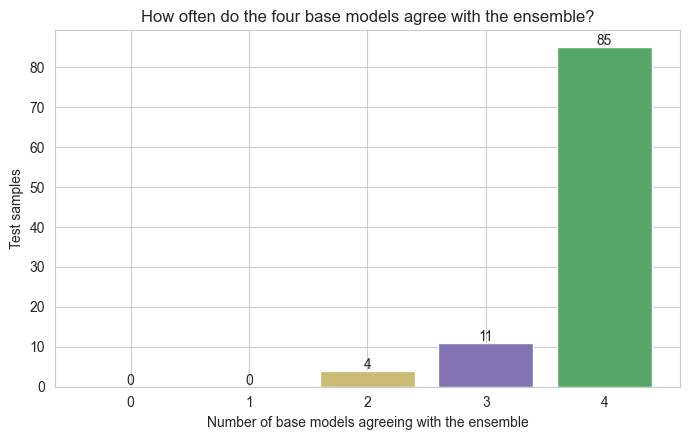

In [27]:
# Count base-model agreement with the ensemble for each test sample.
ensemble_match = (votes_arr == ensemble_pred[None, :]).sum(axis=0)
bins = np.bincount(ensemble_match, minlength=5)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(range(5), bins, color=["#C44E52", "#DD8452", "#CCB974",
                                     "#8172B2", "#55A868"])
for i, v in enumerate(bins):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
ax.set_xlabel("Number of base models agreeing with the ensemble")
ax.set_ylabel("Test samples")
ax.set_title("How often do the four base models agree with the ensemble?")
ax.set_xticks(range(5))
plt.tight_layout()
plt.show()

When all four base models agree, the ensemble prediction is essentially
locked in. The samples where only two or three models agree are the harder
ones — and they're exactly where soft voting helps most, by letting the more
confident models pull the answer in the right direction.

## 8. Conclusion

Two complementary approaches are kept as submissions:

- **ExtraTrees on 30 engineered features** — a transparent classical
  baseline. Every feature has a one-line justification grounded in course
  material (time-domain shape, first-difference shape, periodogram,
  wavelets). Writes `ET-submission.csv`.

- **Soft-voting ensemble of MiniRocket+Ridge, WEASEL v2, RDST, and
  MultiRocket-Hydra** — four modern time-series classifiers, each from a
  different family. The per-model CV scores confirm the individual members
  are competent; the pairwise disagreement and sample-level agreement plots
  show they make *different* mistakes — the necessary condition for soft
  voting to help. Writes `ensemble-submission.csv`.

**The ensemble is our final submission.** The ExtraTrees model is kept for
comparison and to show that a small, interpretable feature set already gets
most of the way there.

### Limits of the evaluation

With only 100 training samples and 10 classes, every CV score carries a
±2pp noise floor. We avoid chasing micro-improvements within that range,
and avoid hyperparameter searches that would over-fit the validation
folds.

### References

**Course material**

1. TSAC, Chapter 10: *Introduction to Spectral Analysis* Course
   material used as the basis for the 30 engineered features (time-domain
   statistics, first-difference statistics, periodogram-based features,
   wavelet decomposition).
2. Machine Learning module — *Classification algorithms.* Course material
   covering logistic regression, random forests, support vector machines,
   and Extra Trees.
3. Pedregosa, F. et al. *Scikit-learn: Machine learning in Python.* JMLR
   12, 2011. — together with the
   [scikit-learn documentation](https://scikit-learn.org/stable/),
   used for all classical model implementations.

**Time-series classification methods**

4. Dempster, A., Schmidt, D. F., & Webb, G. I. *MiniRocket: A very fast
   (almost) deterministic transform for time series classification.*
   KDD 2021.
5. Schäfer, P., & Leser, U. *WEASEL 2.0 — A random dilated dictionary
   transform for fast, accurate and memory constrained time series
   classification.* Machine Learning 112(12), 2023.
6. Guillaume, A., Vrain, C., & Elloumi, W. *Random Dilated Shapelet
   Transform: A new approach for time series shapelets.* ICPRAI 2022.
7. Dempster, A., Schmidt, D. F., & Webb, G. I. *Hydra: competing
   convolutional kernels for fast and accurate time series classification.*
   Data Mining and Knowledge Discovery 37, 2023.